# Restaurant Recommendation via KNN

## Loading the data

In [1]:
import tarfile
import os
import json
import pandas as pd
import numpy as np

In [2]:
tar_path = "/Users/kiradamo/Documents/CSC 577/Final Project/Yelp JSON/yelp_dataset.tar"
extract_path = "/Users/kiradamo/Documents/CSC 577/Final Project/Yelp JSON"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path, members=tar.getmembers())  # keeps it safe

/var/folders/c8/2bjwc5q11jj3f4jtqxxls6gc0000gn/T/ipykernel_6048/2636790333.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path, members=tar.getmembers())  # keeps it safe


In [3]:
business_file = 'yelp_academic_dataset_business.json'
review_file =  'yelp_academic_dataset_review.json'
user_file =  'yelp_academic_dataset_user.json'

In [4]:
business_data = []
with open(f'{extract_path}/{business_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        business_data.append(json.loads(line))

business_df = pd.DataFrame(business_data)
business_df.head()

review_data = []
with open(f'{extract_path}/{review_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        review_data.append(json.loads(line))

review_df = pd.DataFrame(review_data)
review_df.head()

user_data = []
with open(f'{extract_path}/{user_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        user_data.append(json.loads(line))

user_df = pd.DataFrame(user_data)

## Preprocessing and Filtering

## Users

In [5]:
user_df

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,UnHIN6t0MVRdC0Jo9oD9PQ,Shanel,43,2010-10-09 21:28:32,60,5,11,,"xR_8zWgLc9PwKK2lHTLPqg, X-cHFsVb_uFMHpxtWx5RlA...",5,...,0,0,0,0,1,1,2,2,0,0
9997,nbF6fWySgbbD15TGSOKN6Q,Britta,43,2010-09-19 00:13:03,102,18,42,"2010,2011","4xlgvlij2-YRWbjxzFiVFQ, V2OoxojbgbKSlSAv209OcA...",5,...,0,1,1,0,4,2,7,7,0,0
9998,rVuP6BdGt_8QF7PA0kRyvQ,Nel,392,2011-07-15 22:54:35,278,80,67,"2012,2013,2014,2015,2016,2017","os3Q5QS-pkxpIwVeeTB3kA, mV4lknblF-zOKSF8nlGqDA...",9,...,4,1,0,0,2,7,2,2,5,0
9999,fPvAAXp-B-fTS3_HOxvqlg,Jon,76,2008-07-06 04:11:54,97,34,49,,"0jL0CYSScmT7a2L_tiR_OQ, 3jyJ7VIRuKiZDr6WwAvovg...",6,...,0,0,0,0,4,0,3,3,1,1


In [6]:
user_df = user_df[user_df['review_count'] >= 10]

Pruning user variables:

In [7]:
users = user_df[['user_id', 'review_count', 'average_stars']]
users

,user_id,review_count,average_stars
0,qVc8ODYU5SZjKXVBgXdI7w,585,3.91
1,j14WgRoU_-2ZE1aw1dXrJg,4333,3.74
2,2WnXYQFK0hXEoTxPtV2zvg,665,3.32
3,SZDeASXq7o05mMNLshsdIA,224,4.27
4,hA5lMy-EnncsH4JoR-hFGQ,79,3.54
...,...,...,...
9994,iJ49Vf4yOg5uVqNFCk5q-g,27,3.70
9996,UnHIN6t0MVRdC0Jo9oD9PQ,43,4.25
9997,nbF6fWySgbbD15TGSOKN6Q,43,3.74
9998,rVuP6BdGt_8QF7PA0kRyvQ,392,3.44


## Business

Pruning business variables:

In [8]:
businesses = business_df[['business_id', 'stars', 'review_count', 'is_open', 'attributes', 'categories']]
businesses

,business_id,stars,review_count,is_open,attributes,categories
0,Pns2l4eNsfO8kk83dixA6A,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food"
...,...,...,...,...,...,...
9996,N-4ZOrM_qAnzBiCsJ7-ENA,3.0,16,1,"{'RestaurantsAttire': 'u'casual'', 'BikeParkin...","Canadian (New), American (New), Restaurants"
9997,KqvaJX11rb4Hp70D8Dw4oQ,4.0,10,1,"{'Alcohol': ''full_bar'', 'HappyHour': 'False'...","Bars, Nightlife, Airport Lounges"
9998,Yv6HUVu7fRMnt_NtGdVQBw,3.5,158,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Mexican"
9999,rwsVxJqln-0HZFg1zxWtwQ,4.5,7,1,{'BusinessAcceptsCreditCards': 'True'},"Professional Services, Local Services, Printin..."


### Categories

In [9]:
#only restaurants
businesses = businesses[businesses['categories'].str.contains("Restaurants", na=False)]

In [10]:
#only restaurants that are still open
businesses = businesses[businesses['is_open'] == 1]
businesses

,business_id,stars,review_count,is_open,attributes,categories
3,MTSW4McQd7CbVtyjqoe9mw,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
5,CF33F8-E6oudUQ46HnavjQ,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea..."
9,bBDDEgkFA1Otx9Lfe7BZUQ,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,..."
11,eEOYSgkmpB90uNA7lDOMRA,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks"
12,il_Ro8jwPlHresjw9EGmBg,2.5,28,1,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B..."
...,...,...,...,...,...,...
9990,uz3bn1LnXUGPteDoHYhcRQ,1.5,19,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Chicken Shop, Restaurants, Fast Food, Chicken ..."
9993,vgZwA2X7X5oGcui9BDBgbw,4.0,69,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Bakeries, Farmers Market, Restaurants, Breakfa..."
9996,N-4ZOrM_qAnzBiCsJ7-ENA,3.0,16,1,"{'RestaurantsAttire': 'u'casual'', 'BikeParkin...","Canadian (New), American (New), Restaurants"
9998,Yv6HUVu7fRMnt_NtGdVQBw,3.5,158,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Mexican"


In [11]:
businesses = businesses.drop(columns=['is_open'])

In [12]:
businesses

,business_id,stars,review_count,attributes,categories
3,MTSW4McQd7CbVtyjqoe9mw,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
5,CF33F8-E6oudUQ46HnavjQ,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea..."
9,bBDDEgkFA1Otx9Lfe7BZUQ,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,..."
11,eEOYSgkmpB90uNA7lDOMRA,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks"
12,il_Ro8jwPlHresjw9EGmBg,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B..."
...,...,...,...,...,...
9990,uz3bn1LnXUGPteDoHYhcRQ,1.5,19,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Chicken Shop, Restaurants, Fast Food, Chicken ..."
9993,vgZwA2X7X5oGcui9BDBgbw,4.0,69,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Bakeries, Farmers Market, Restaurants, Breakfa..."
9996,N-4ZOrM_qAnzBiCsJ7-ENA,3.0,16,"{'RestaurantsAttire': 'u'casual'', 'BikeParkin...","Canadian (New), American (New), Restaurants"
9998,Yv6HUVu7fRMnt_NtGdVQBw,3.5,158,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Mexican"


In [13]:
businesses['categories'] = businesses['categories'].str.split(', ')

In [14]:
#turns categories into a list of individual categories rather than one long string
categories_dummies = businesses['categories'].explode().str.get_dummies().groupby(level=0).max()
business_features = pd.concat([businesses[['business_id']], categories_dummies], axis=1)
#since all categories are restaurants, the restaurants will be dropped
categories_dummies = categories_dummies.drop(columns=['Restaurants'], errors='ignore')
business_features = pd.concat([businesses[['business_id']], categories_dummies], axis=1)

In [15]:
categories_dummies

,Acai Bowls,Accessories,Active Life,Adult Entertainment,Afghan,African,American (New),American (Traditional),Amusement Parks,Appliances & Repair,...,Windshield Installation & Repair,Wine & Spirits,Wine Bars,Wine Tasting Classes,Wine Tasting Room,Wineries,Women's Clothing,Wraps,Yelp Events,Yoga
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Attributes

In [16]:
businesses['attributes']

3        {'RestaurantsDelivery': 'False', 'OutdoorSeati...
5        {'BusinessParking': 'None', 'BusinessAcceptsCr...
9        {'RestaurantsAttire': ''casual'', 'Restaurants...
11       {'Alcohol': ''none'', 'OutdoorSeating': 'None'...
12       {'RestaurantsReservations': 'False', 'Restaura...
                               ...                        
9990     {'BusinessAcceptsCreditCards': 'True', 'Restau...
9993     {'BusinessAcceptsCreditCards': 'True', 'Restau...
9996     {'RestaurantsAttire': 'u'casual'', 'BikeParkin...
9998     {'BusinessAcceptsCreditCards': 'True', 'Restau...
10000    {'RestaurantsPriceRange2': '1', 'RestaurantsAt...
Name: attributes, Length: 2300, dtype: object

In [17]:
businesses['attributes'] = businesses['attributes'].apply(lambda x: {} if pd.isna(x) else x)
businesses['attributes_list'] = businesses['attributes'].apply(lambda d: [f"{k}={v}" for k,v in d.items()])
attributes_dummies = businesses['attributes'].explode().str.get_dummies().groupby(level=0).max()

In [18]:
business_features = pd.concat(
    [businesses[['business_id', 'categories', 'review_count']], categories_dummies, attributes_dummies],
    axis=1
)

In [19]:
print("Feature matrix shape:", business_features.shape)
print("Sample columns:", business_features.columns[:20])

Feature matrix shape: (2300, 385)
Sample columns: Index(['business_id', 'categories', 'review_count', 'Acai Bowls',
       'Accessories', 'Active Life', 'Adult Entertainment', 'Afghan',
       'African', 'American (New)', 'American (Traditional)',
       'Amusement Parks', 'Appliances & Repair', 'Arabic', 'Arcades',
       'Argentine', 'Armenian', 'Art Galleries', 'Arts & Crafts',
       'Arts & Entertainment'],
      dtype='object')


In [20]:
business_features.columns

Index(['business_id', 'categories', 'review_count', 'Acai Bowls',
       'Accessories', 'Active Life', 'Adult Entertainment', 'Afghan',
       'African', 'American (New)',
       ...
       'RestaurantsCounterService', 'RestaurantsDelivery',
       'RestaurantsGoodForGroups', 'RestaurantsPriceRange2',
       'RestaurantsReservations', 'RestaurantsTableService',
       'RestaurantsTakeOut', 'Smoking', 'WheelchairAccessible', 'WiFi'],
      dtype='object', length=385)

Now the business data is filtered to be only businesses that are classified as restaurants and are still open. All categories and attributes were converted into binary columns and joined as a single feature matrix. There are attributes and categories that are not relevant to food and will cause noise in the data. There may also be abstract recommendations as the number of recommended neighbors increases. For time's sake and to prevent data loss, these irrelevant categories and attributes will be kept in the dataset.

## Reviews

In [21]:
reviews = review_df[['user_id','business_id','stars']]

This model is not using TFxIDF similarity recommendation. There is another model in the project that utilizes this method. For this model, text is discarded.

In [22]:
#need reviews to only reflect the businesses that are restaurants and still open.
reviews = reviews[reviews['business_id'].isin(business_features['business_id'])]
reviews

,user_id,business_id,stars
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0
3,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0
11,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4.0
12,9OAtfnWag-ajVxRbUTGIyg,lj-E32x9_FA7GmUrBGBEWg,4.0
14,4Uh27DgGzsp6PqrH913giQ,otQS34_MymijPTdNBoBdCw,4.0
...,...,...,...
9982,FM3hremwwIZCDmqlkUm-fg,T-uphPk44OFt6sR8F-0uHA,4.0
9987,7KwiZTsM0dXt3bh0Ng5K6g,DvkSkF83xDONjkNIoEPRnQ,5.0
9994,pg0GI_LBpsX06a8eN7Ff5A,0qu0fNTOsSmuREYVIMPuIQ,4.0
9998,OnIklvzKDpk1BduC84TrTA,2XYPFRm7teCUr3eGsB2-qw,5.0


## User Profiles

In [23]:
#left join table
reviews_with_features = reviews.merge(business_features, on='business_id', how='left')

In [24]:
reviews_with_features

,user_id,business_id,stars,categories,review_count,Acai Bowls,Accessories,Active Life,Adult Entertainment,Afghan,...,RestaurantsCounterService,RestaurantsDelivery,RestaurantsGoodForGroups,RestaurantsPriceRange2,RestaurantsReservations,RestaurantsTableService,RestaurantsTakeOut,Smoking,WheelchairAccessible,WiFi
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"[Restaurants, Breakfast & Brunch, Food, Juice ...",169,0,0,0,0,0,...,0,1,1,1,1,1,1,0,1,1
1,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,"[Halal, Pakistani, Restaurants, Indian]",181,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
2,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4.0,"[Beer, Wine & Spirits, Cafes, Coffee & Tea, Re...",1379,0,0,0,0,0,...,0,1,1,1,1,1,1,0,0,1
3,9OAtfnWag-ajVxRbUTGIyg,lj-E32x9_FA7GmUrBGBEWg,4.0,"[Bars, Pizza, Nightlife, Cocktail Bars, Italia...",366,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,4Uh27DgGzsp6PqrH913giQ,otQS34_MymijPTdNBoBdCw,4.0,"[Restaurants, Tacos, Mexican, Hot Dogs, Breakf...",492,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3503,FM3hremwwIZCDmqlkUm-fg,T-uphPk44OFt6sR8F-0uHA,4.0,"[American (New), Food, Restaurants, American (...",289,0,0,0,0,0,...,0,1,1,1,1,1,1,0,1,1
3504,7KwiZTsM0dXt3bh0Ng5K6g,DvkSkF83xDONjkNIoEPRnQ,5.0,"[Restaurants, Street Vendors, Wine Bars, Food,...",267,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
3505,pg0GI_LBpsX06a8eN7Ff5A,0qu0fNTOsSmuREYVIMPuIQ,4.0,"[American (Traditional), Restaurants, Bars, Ni...",1018,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
3506,OnIklvzKDpk1BduC84TrTA,2XYPFRm7teCUr3eGsB2-qw,5.0,"[Thai, Restaurants]",195,0,0,0,0,0,...,0,1,1,1,1,1,1,0,0,1


In [25]:
feature_cols = [c for c in reviews_with_features.columns 
                if c not in ['user_id', 'review_count', 'business_id', 'stars'] 
                and pd.api.types.is_numeric_dtype(reviews_with_features[c])]

#multiply numeric features by stars
reviews_with_features[feature_cols] = reviews_with_features[feature_cols].multiply(reviews_with_features['stars'], axis=0)

In [26]:
reviews_with_features

,user_id,business_id,stars,categories,review_count,Acai Bowls,Accessories,Active Life,Adult Entertainment,Afghan,...,RestaurantsCounterService,RestaurantsDelivery,RestaurantsGoodForGroups,RestaurantsPriceRange2,RestaurantsReservations,RestaurantsTableService,RestaurantsTakeOut,Smoking,WheelchairAccessible,WiFi
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"[Restaurants, Breakfast & Brunch, Food, Juice ...",169,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,3.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0
1,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,"[Halal, Pakistani, Restaurants, Indian]",181,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,0.0,5.0,0.0,0.0,5.0
2,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4.0,"[Beer, Wine & Spirits, Cafes, Coffee & Tea, Re...",1379,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,0.0,4.0
3,9OAtfnWag-ajVxRbUTGIyg,lj-E32x9_FA7GmUrBGBEWg,4.0,"[Bars, Pizza, Nightlife, Cocktail Bars, Italia...",366,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0
4,4Uh27DgGzsp6PqrH913giQ,otQS34_MymijPTdNBoBdCw,4.0,"[Restaurants, Tacos, Mexican, Hot Dogs, Breakf...",492,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3503,FM3hremwwIZCDmqlkUm-fg,T-uphPk44OFt6sR8F-0uHA,4.0,"[American (New), Food, Restaurants, American (...",289,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,4.0,4.0
3504,7KwiZTsM0dXt3bh0Ng5K6g,DvkSkF83xDONjkNIoEPRnQ,5.0,"[Restaurants, Street Vendors, Wine Bars, Food,...",267,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3505,pg0GI_LBpsX06a8eN7Ff5A,0qu0fNTOsSmuREYVIMPuIQ,4.0,"[American (Traditional), Restaurants, Bars, Ni...",1018,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3506,OnIklvzKDpk1BduC84TrTA,2XYPFRm7teCUr3eGsB2-qw,5.0,"[Thai, Restaurants]",195,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,5.0,5.0,0.0,0.0,5.0


By multiplying the binary columns by the stars, the rows now become weighted vectors. To find similarity, user profiles will need to be made so the reviews will be grouped by user_id. 

In [27]:
user_profiles = reviews_with_features.groupby('user_id')[feature_cols].sum()
#going from weighted features to weighted averages
user_profiles = user_profiles.divide(reviews_with_features.groupby('user_id')['stars'].sum(), axis=0)

In [28]:
reviews_with_features[feature_cols] = reviews_with_features[feature_cols].astype(float)
business_matrix = reviews_with_features.groupby('business_id')[feature_cols].first()
business_matrix.head()

,Acai Bowls,Accessories,Active Life,Adult Entertainment,Afghan,African,American (New),American (Traditional),Amusement Parks,Appliances & Repair,...,RestaurantsCounterService,RestaurantsDelivery,RestaurantsGoodForGroups,RestaurantsPriceRange2,RestaurantsReservations,RestaurantsTableService,RestaurantsTakeOut,Smoking,WheelchairAccessible,WiFi
business_id,,,,,,,,,,,,,,,,,,,,,
-2ke_JDOpgTZWqirMFjZcw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0
-3AooxIkg38UyUdlz5oXdw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,4.0,4.0
-D_L4GHXJQvy2wv0RkrupA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,0.0,5.0,0.0,0.0,5.0
-If0ps0QhOLCYVWQWs9RYg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,0.0,5.0,0.0,0.0,5.0
-JStjL-8mRZq4ov4uI1FaQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,5.0,5.0,5.0,5.0,5.0,0.0,5.0,5.0


## Recommendation

In [29]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [30]:
#grabbing names of businesses
business_lookup = business_df[['business_id', 'name', 'stars', 'review_count', 'is_open', 'attributes', 'categories']]
business_lookup = business_lookup[business_lookup['categories'].str.contains("Restaurants", na=False)]
business_loopkup = business_lookup[business_lookup['is_open'] == 1]
business_lookup = business_lookup[['business_id','name','categories']].drop_duplicates().set_index('business_id')

In [38]:
test_reviews = reviews.groupby('user_id').sample(n=1, random_state=42)
train_reviews = reviews.drop(test_reviews.index)

print(f"Train reviews: {len(train_reviews)}, Test reviews: {len(test_reviews)}")

Train reviews: 68, Test reviews: 3440


In [32]:
reviews_with_features_train = train_reviews.merge(business_features, on='business_id', how='left')

feature_cols = [
    c for c in reviews_with_features_train.columns 
    if c not in ['user_id', 'review_count', 'business_id', 'stars'] 
    and pd.api.types.is_numeric_dtype(reviews_with_features_train[c])
]

reviews_with_features_train[feature_cols] = reviews_with_features_train[feature_cols].multiply(
    reviews_with_features_train['stars'], axis=0
)

user_profiles_train = reviews_with_features_train.groupby('user_id')[feature_cols].sum()
user_profiles_train = user_profiles_train.divide(
    reviews_with_features_train.groupby('user_id')['stars'].sum(), axis=0
)

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

def content_based_recommend_user_ranked(user_id, k=5, user_profiles=None, train_reviews=None):
    # Cold start
    if user_id not in user_profiles.index:
        top_businesses = (
            train_reviews.groupby('business_id')
            .size()
            .sort_values(ascending=False)
            .head(k)
            .reset_index()
        )
        top_businesses = top_businesses.merge(
            businesses[['business_id','categories']],
            on='business_id',
            how='left'
        )
        top_businesses['similarity'] = None
        top_businesses['rank'] = np.arange(1, len(top_businesses)+1)
        return top_businesses[['rank','business_id','categories','similarity']]

    user_vector = user_profiles.loc[user_id].values.reshape(1, -1)
    sims = cosine_similarity(business_matrix.values, user_vector).flatten()

    # only use train interactions
    rated_ids = train_reviews[train_reviews['user_id']==user_id]['business_id'].tolist()
    idx = np.argsort(sims)[::-1]
    idx = [i for i in idx if business_matrix.index[i] not in rated_ids]

    top_idx = idx[:k]
    top_sims = sims[top_idx]

    top_businesses = business_matrix.iloc[top_idx].reset_index()[['business_id']]
    top_businesses = top_businesses.join(business_lookup, on='business_id')
    top_businesses['similarity'] = top_sims
    top_businesses['rank'] = np.arange(1, len(top_idx)+1)

    return top_businesses[['rank','business_id','name','categories','similarity']]

In [34]:
sample_users = user_profiles_train.index[:5]

for user_id in sample_users:
    print(f"\nTop 5 recommendations for user {user_id}:\n")
    
    # Get recommendations using train-only data
    recs = content_based_recommend_user_ranked(
        user_id,
        k=5,
        user_profiles=user_profiles_train,
        train_reviews=train_reviews
    )
    
    for _, row in recs.iterrows():
        if row['similarity'] is not None:
            print(f"Rank {row['rank']}: {row['name']} ({row['categories']}) - similarity: {row['similarity']:.3f}")
        else:
            print(f"Rank {row['rank']}: {row['categories']} - popularity-based")


Top 5 recommendations for user 0WqEkKMu03irkMiEtsFxZg:

Rank 1: Captain Bill's Oyster Bar (American (New), Cocktail Bars, Seafood, Bars, Restaurants, Nightlife) - similarity: 0.907
Rank 2: Prep & Pastry (Restaurants, Cocktail Bars, Bars, Comfort Food, American (New), Sandwiches, Nightlife, Breakfast & Brunch) - similarity: 0.895
Rank 3: Salty's Island Bar & Grille (Mexican, American (New), Seafood, Bars, Sandwiches, Restaurants, Nightlife) - similarity: 0.879
Rank 4: Earl's New American (Nightlife, American (New), Bars, Seafood, Restaurants, Wine Bars, Cocktail Bars) - similarity: 0.878
Rank 5: Katie's Restaurant & Bar (Restaurants, Bars, Nightlife, American (Traditional), Cajun/Creole, Seafood) - similarity: 0.878

Top 5 recommendations for user 1zWDmN9_FfE2dViyUEztTw:

Rank 1: Domino's Pizza (Restaurants, Sandwiches, Chicken Wings, Pizza) - similarity: 0.707
Rank 2: Domino's Pizza (Restaurants, Pizza, Sandwiches, Chicken Wings) - similarity: 0.629
Rank 3: Drexel Hill Pizza & Grill (

## Evaluation

In [35]:
def evaluate_dataset(reviews_df, k_values, user_profiles, train_reviews):
    results = []
    for uid in reviews_df['user_id'].unique():
        true_items = reviews_df[reviews_df['user_id']==uid]['business_id'].tolist()
        if not true_items:
            continue
        
        max_k = max(k_values)
        pred_items = content_based_recommend_user_ranked(
            uid, k=max_k, user_profiles=user_profiles, train_reviews=train_reviews
        )['business_id'].tolist()
        
        user_result = {'user_id': uid}
        for k in k_values:
            # simple Recall@K / Precision@K
            hits = len(set(pred_items[:k]) & set(true_items))
            user_result[f'Recall@{k}'] = hits / len(true_items)
            user_result[f'Precision@{k}'] = hits / k
        results.append(user_result)
    
    return pd.DataFrame(results)

In [44]:
k_values = list(range(1, 21))  # use 1–20 for clarity

train_results_df = evaluate_dataset(train_reviews, k_values, user_profiles_train, train_reviews)
test_results_df = evaluate_dataset(test_reviews, k_values, user_profiles_train, train_reviews)

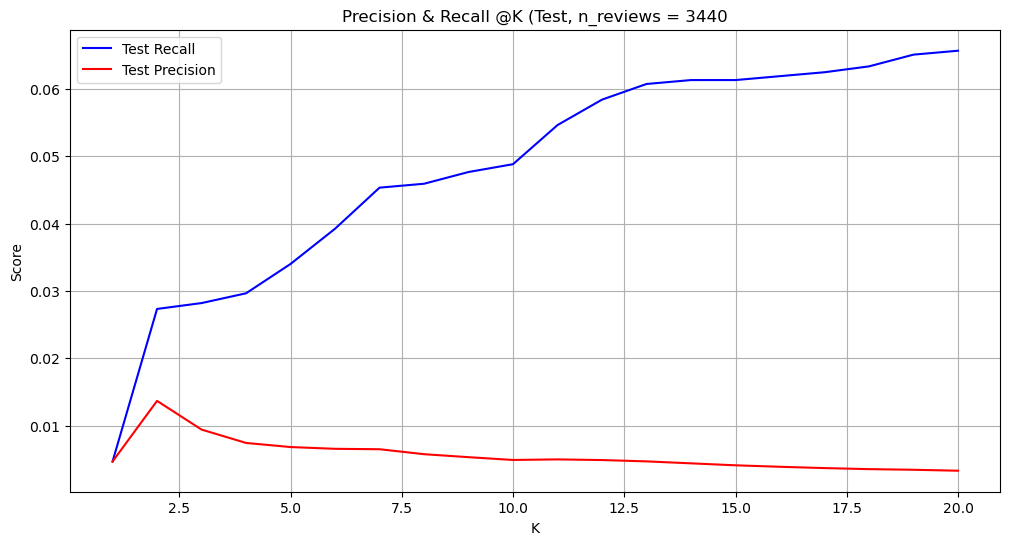

In [45]:
train_avg = train_results_df.mean(numeric_only=True)
test_avg = test_results_df.mean(numeric_only=True)

train_recall = [train_avg[f'Recall@{k}'] for k in k_values]
train_precision = [train_avg[f'Precision@{k}'] for k in k_values]

test_recall = [test_avg[f'Recall@{k}'] for k in k_values]
test_precision = [test_avg[f'Precision@{k}'] for k in k_values]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Recall
plt.plot(k_values, test_recall, label='Test Recall', linestyle='-', color='blue')
plt.plot(k_values, test_precision, label='Test Precision', linestyle='-', color='red')

plt.xlabel('K')
plt.ylabel('Score')
plt.title(f'Precision & Recall @K (Test, n_reviews = {len(test_reviews)}')
plt.grid(True)
plt.legend()
plt.show()